# Conjunto de datos sobre viviendas en Boston

El conjunto de datos sobre vivienda en Boston se deriva de la información recopilada por el Servicio de Censo de los Estados Unidos sobre la vivienda en el área de Boston, Massachusetts. A continuación se describen las columnas del conjunto de datos:

- CRIM: tasa de criminalidad per cápita por ciudad.
- ZN: proporción de terreno residencial zonificado para lotes de más de 25,000 pies cuadrados.
- INDUS: proporción de acres de negocios no minoristas por ciudad.
- CHAS: variable ficticia del río Charles (1 si la zona limita con el río; 0 en caso contrario).
- NOX: concentración de óxidos nítricos (partes por 10 millones).
- RM: número medio de habitaciones por vivienda.
- AGE: proporción de viviendas ocupadas por sus propietarios construidas antes de 1940.
- DIS: distancias ponderadas a cinco centros de empleo de Boston.
- RAD: índice de accesibilidad a autopistas radiales.
- TAX: tasa del impuesto sobre el valor total de la propiedad por cada 10 000 dólares.
- PTRATIO: ratio alumno-profesor por ciudad.
- B: 1000(Bk - 0,63)^2, donde Bk es la proporción de personas de raza negra por ciudad.
- LSTAT: porcentaje de población con un nivel socioeconómico bajo.
- MEDV: valor medio de las viviendas ocupadas por sus propietarios en miles de dólares.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor 
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [23]:
ruta = r"C:\Users\luis\Dropbox\Data-science\Proyectos\housing.csv"
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

data = pd.read_csv(ruta, delim_whitespace=True, header=None, names=column_names)
data.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


Desde el principio, dos columnas de datos muestran resúmenes interesantes. Son: ZN (proporción de terreno residencial zonificado para lotes de más de 25,000 pies cuadrados) con 0 para los percentiles 25 y 50. En segundo lugar, CHAS: variable ficticia del río Charles (1 si la parcela limita con el río; 0 en caso contrario) con 0 para los percentiles 25, 50 y 75. Estos resúmenes son comprensibles, ya que ambas variables son variables condicionales + categóricas. La primera suposición sería que estas columnas pueden no ser útiles en tareas de regresión, como la predicción del MEDV (valor medio de las viviendas ocupadas por sus propietarios).

Otro dato interesante sobre el conjunto de datos es el valor máximo de MEDV. Según la descripción original de los datos, la variable n.º 14 parece estar censurada en 50,00 (lo que corresponde a un precio medio de 50 000 dólares). Basándonos en eso, los valores superiores a 50,00 pueden no ser útiles para predecir MEDV. Trazamos el conjunto de datos y observamos tendencias y estadísticas interesantes.

Entonces en el presente trabajo nuestra variable objetivo es MEDV.

# Análisis Exploratorio de Datos

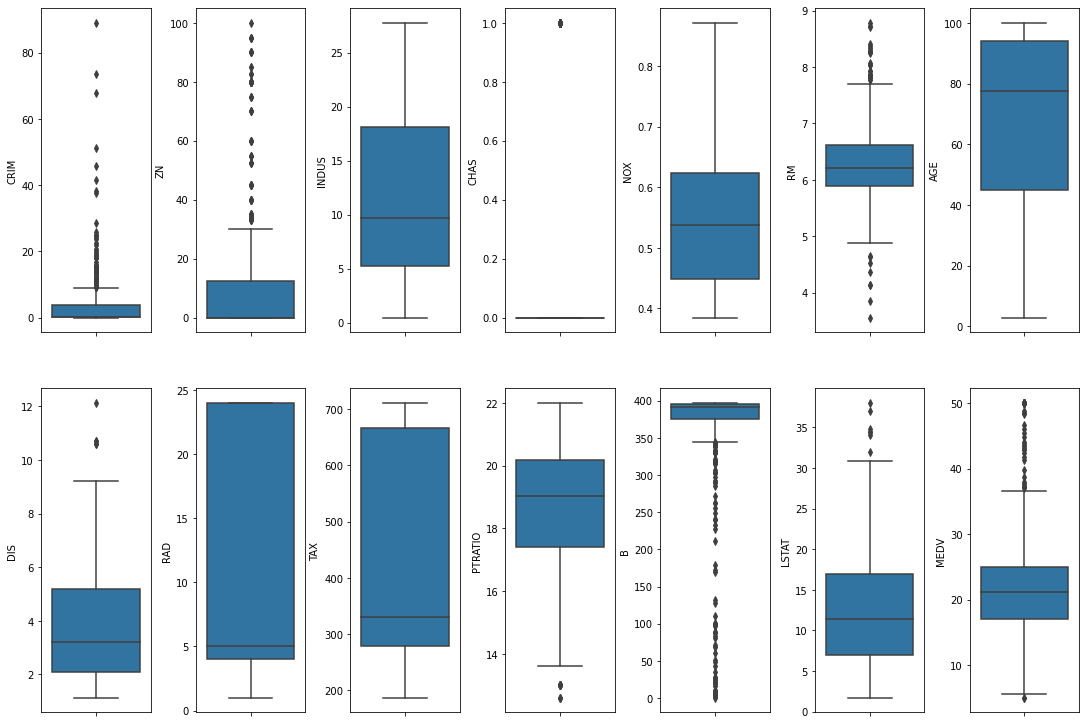

In [24]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(15,10))
index = 0
axs = axs.flatten()

for k, v in data.items():
    sns.boxplot(y=k, data=data, ax=axs[index])
    index += 1

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

En el Boxplot podemos observar que las variables: CRIM, ZN, RM, B. Tienen valores atipicos. A continuación veremos el % de los valores atipicos en cada variable.

In [25]:
for k, v in data.items():
    q1 = v.quantile(0.25)
    q3 = v.quantile(0.75)
    irq = q3-q1
    v_col = v[(v<=q1 - 1.5*irq) | (v >= q3 + 1.5*irq)]
    perc = np.shape(v_col)[0]*100 / np.shape(data)[0]
    print("Column %s outliers = %.2f%%" % (k, perc))

Column CRIM outliers = 13.04%
Column ZN outliers = 13.44%
Column INDUS outliers = 0.00%
Column CHAS outliers = 100.00%
Column NOX outliers = 0.00%
Column RM outliers = 5.93%
Column AGE outliers = 0.00%
Column DIS outliers = 0.99%
Column RAD outliers = 0.00%
Column TAX outliers = 0.00%
Column PTRATIO outliers = 2.96%
Column B outliers = 15.22%
Column LSTAT outliers = 1.38%
Column MEDV outliers = 7.91%


Removeremos los outlier para MEDV, entonces solo conservamos valores menores que 50

In [26]:
data = data[~(data['MEDV']>= 50.0)]

Ahora visualisamos la distribución de las variables, para mejor entendimiento de su comportamiento.

c:\Users\luis\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
c:\Users\luis\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
c:\Users\luis\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level 

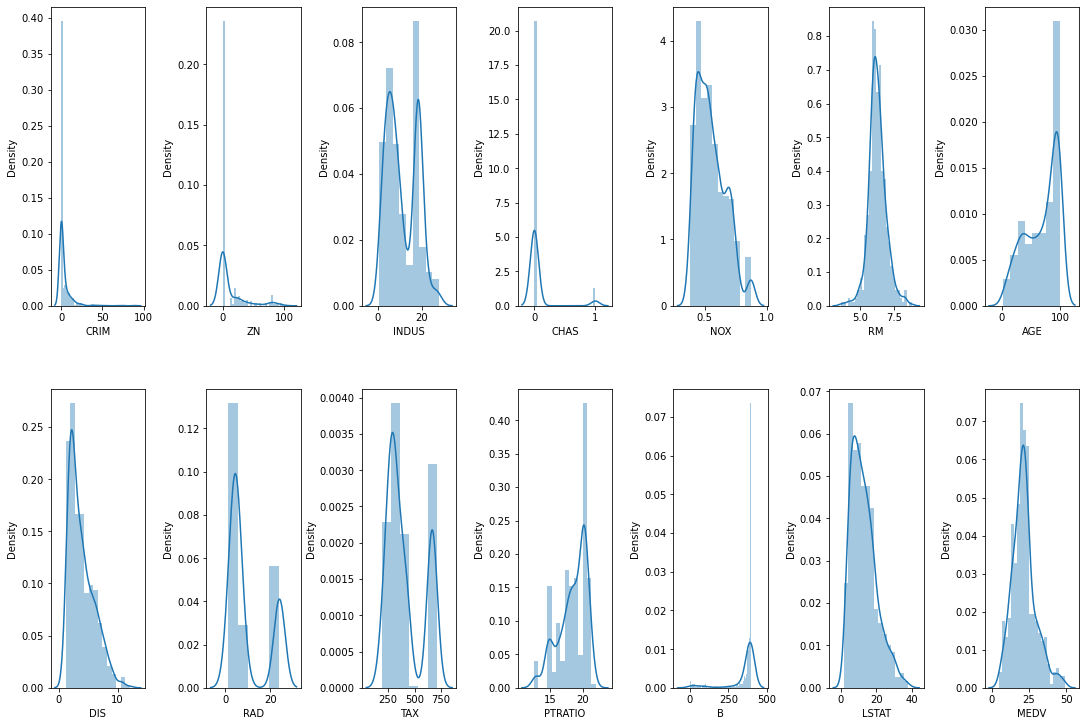

In [27]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(15,10))
index = 0
axs = axs.flatten()

for k, v in data.items():
    sns.distplot(v, ax=axs[index]) 
    index += 1

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)


El histograma también muestra que las columnas CRIM, ZN y B tienen distribuciones muy sesgadas. Además, MEDV parece tener una distribución normal (las predicciones) y otras columnas parecen tener una distribución normal o bimodal de datos, excepto CHAS (que es una variable discreta).

Ahora representemos gráficamente la correlación por pares en los datos.

<AxesSubplot:>

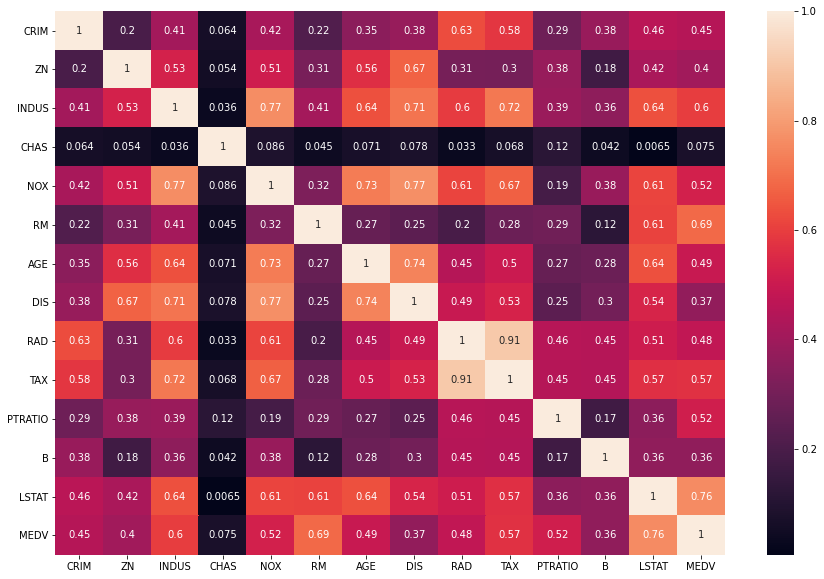

In [28]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr().abs(), annot=True)

La matriz de correlación nos deja información valiosa para nuestro proceso, por ejemplo podemos ver que las variables TAX y RAD tienen una alta correlación. Además tenemos que las columnas: LSTAT, INDUS, RM, TAX, NOX, PTRAIO tienen una correlación alrededor de 0.5 con MEDV, lo cual es un indicio para usar como predictores. 

A continuación realizamos una gráfica de las anteriores variables mencionadas vs MEDV. 

Primero realizamos un escalado de las variables para mejor desempeño. Para esto hacemos uso del paquete preprocessing.

In [29]:
min_max_scaler = MinMaxScaler()
columns_select = ['LSTAT', 'INDUS', 'NOX', 'PTRATIO', 'RM', 'TAX', 'DIS', 'AGE']
X = data.loc[:, columns_select]
y = data['MEDV']
X = pd.DataFrame(data=min_max_scaler.fit_transform(X), columns=columns_select)

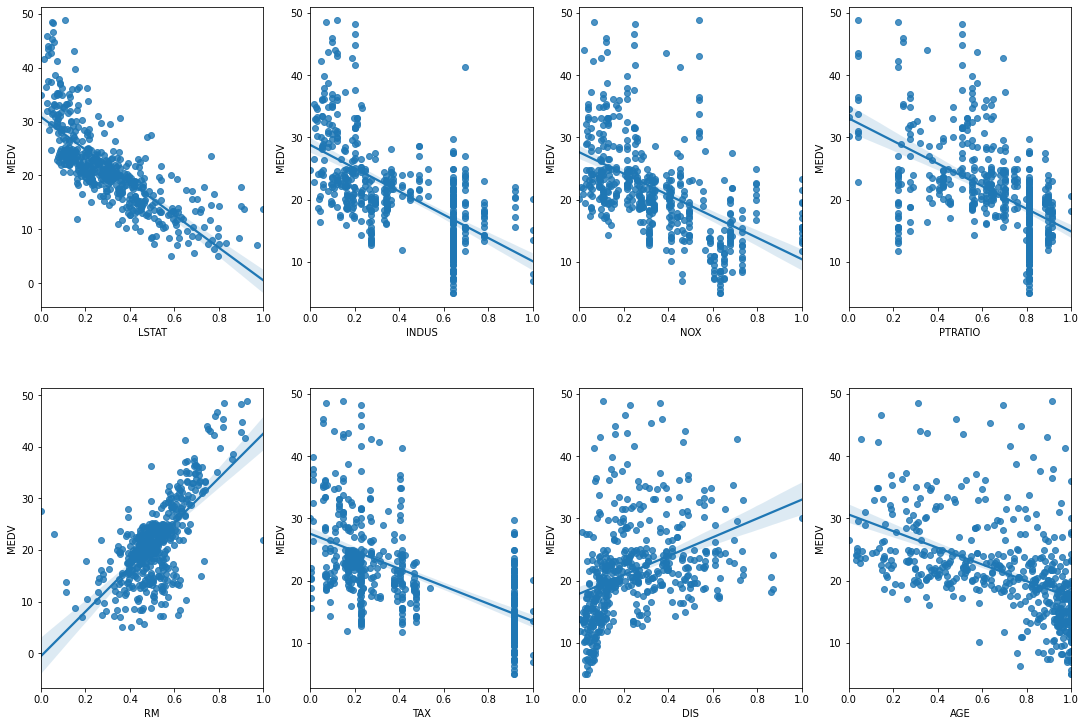

In [30]:
#Grafico variables seleccionadas vs MEDV
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(15,10))
index=0
axs=axs.flatten()

for i, k in enumerate(columns_select):
    sns.regplot(y=y, x=X[k], ax=axs[i])

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=77)
print('Train:', X_train.shape, y_train.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (343, 8) (343,)
Test: (147, 8) (147,)


# Decision Tree

In [32]:
f = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=77
)

# Entrenamos el Árbol de Decisión
f = f.fit(X_train, y_train)

feature_names = list(X_train.columns)
ft = export_text(f, feature_names=feature_names)
print(ft)

|--- LSTAT <= 0.16
|   |--- RM <= 0.64
|   |   |--- RM <= 0.57
|   |   |   |--- TAX <= 0.07
|   |   |   |   |--- value: [28.70]
|   |   |   |--- TAX >  0.07
|   |   |   |   |--- DIS <= 0.10
|   |   |   |   |   |--- RM <= 0.54
|   |   |   |   |   |   |--- LSTAT <= 0.12
|   |   |   |   |   |   |   |--- value: [27.00]
|   |   |   |   |   |   |--- LSTAT >  0.12
|   |   |   |   |   |   |   |--- value: [27.50]
|   |   |   |   |   |--- RM >  0.54
|   |   |   |   |   |   |--- value: [23.30]
|   |   |   |   |--- DIS >  0.10
|   |   |   |   |   |--- AGE <= 0.14
|   |   |   |   |   |   |--- RM <= 0.52
|   |   |   |   |   |   |   |--- LSTAT <= 0.14
|   |   |   |   |   |   |   |   |--- DIS <= 0.36
|   |   |   |   |   |   |   |   |   |--- value: [25.20]
|   |   |   |   |   |   |   |   |--- DIS >  0.36
|   |   |   |   |   |   |   |   |   |--- value: [25.30]
|   |   |   |   |   |   |   |--- LSTAT >  0.14
|   |   |   |   |   |   |   |   |--- value: [24.70]
|   |   |   |   |   |   |--- RM >  0.52
|   | 

## Prediction performance

In [33]:
y_pred = f.predict(X_test)

print('Mean aboslute error :', metrics.mean_absolute_error(y_test, y_pred))
print('Mean squared error :', metrics.mean_squared_error(y_test, y_pred))
print('R2 :', metrics.r2_score(y_test, y_pred))

Mean aboslute error : 2.75578231292517
Mean squared error : 14.456530612244899
R2 : 0.7645516186930799


## Tuning Hyperparameters

In [34]:
#Definimos grilla de hiperparametros
param_grid = {
    'max_depth': [3,5,10,15,20, None],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': ['sqrt', 'log2', None]
}

#Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=77)

grid_search = GridSearchCV(
    estimator=f,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

grid_result = grid_search.fit(X_train, y_train)

print("\n" + "="*50)
print("Mejores Hiperparametros :")
print(f"Mejor Score (Negativo MSE): {grid_result.best_score_:.4f}")
print(f"Mejores Parámetros : {grid_result.best_params_}")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits



Mejores Hiperparametros :
Mejor Score (Negativo MSE): -13.3618
Mejores Parámetros : {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 20}


## Decision Tree - Óptimo

In [35]:
f = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=15,
    max_features=None,
    min_samples_split=20,
    min_samples_leaf=1,
    random_state=77
)

# Entrenamos el Árbol de Decisión
f = f.fit(X_train, y_train)
y_pred = f.predict(X_test)

## Prediction Desempeño

In [36]:
print('Mean aboslute error :', metrics.mean_absolute_error(y_test, y_pred))
print('Mean squared error :', metrics.mean_squared_error(y_test, y_pred))
print('R2 :', metrics.r2_score(y_test, y_pred))

Mean aboslute error : 2.6995713188822275
Mean squared error : 13.644373377078963
R2 : 0.777778935226727


Como podemos ver, nuestra óptimización de hiperparametros fue exitoso, dado que se muestran breves mejoras en el desempeño de las medidas. Poe ejemplo, tenemos que tanto el error abosluto como el error cuadratico medio disminuyeron. Y por su parte, el R2 aumento, es decir, el desempeño del algoritmo mejoro con el tuneo de los hiperparamtros.

# Random Forest

In [37]:
f = RandomForestRegressor(
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_estimators=100,
    max_features=13,
    random_state=77
)

f = f.fit(X_train, y_train)
y_pred = f.predict(X_test)

## Predicition Performance

In [38]:
print(f'Mean Absolute Error : {metrics.mean_absolute_error(y_test, y_pred)}')
print(f'Mean Squared Error : {metrics.mean_squared_error(y_test, y_pred)}')
print(f'R2 : {metrics.r2_score(y_test, y_pred)}')

Mean Absolute Error : 2.141408163265306
Mean Squared Error : 9.380803027210893
R2 : 0.8472181917392363


## Tuning Hyperparameters

Para el tuneo de hiperaparametros para este algoritmo en particular lo realizaremos de un forma distinta a la realizada con árboles de decisión. En este caso, el tuneo se realizara dos veces, primero para elegir el mejor número de 'estimators' y luego un tuneo para los hiperparametros faltantes.

In [39]:
#paso 1, obtenemos el número óptimo de 'estimators'
param_grid_1 = {
    'n_estimators': [50,100,200,300]
}

kfols = KFold(n_splits=5, shuffle=True, random_state=77)

grid_1 = GridSearchCV(
    estimator=f,
    param_grid = param_grid_1,
    scoring = 'neg_root_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)
grid_result_1 = grid_1.fit(X_train, y_train)

print(f"Mejor n_estimators: {grid_result_1.best_params_['n_estimators']}")
print(f"Mejor Score (Neg RMSE): {grid_result_1.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejor n_estimators: 200
Mejor Score (Neg RMSE): -3.0707


In [40]:
#grilla para hiperparametros faltantes
best_estimator = grid_result_1.best_params_['n_estimators']

param_grid_2 = {
    'n_estimators': [best_estimator],
    'max_depth': [None, 15,25,35],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt', 0.33,0.2]
}

rf_2 = RandomForestRegressor(
    n_estimators=best_estimator,
    random_state=77,
    n_jobs=-1
)

grid_2 = GridSearchCV(
    estimator=rf_2,
    param_grid=param_grid_2,
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    n_jobs=1,
    verbose=1
)
grid_result_2 = grid_2.fit(X_train, y_train)

print(f"\n" + "=*60")
print("Ánalisis final del mejor modelo")
print("="*60)
print(f"Mejores hiperparametros: {grid_result_2.best_params_}")
print(f"Mejor Score (Negativo RMSE) : {grid_result_2.best_score_:.4f}")
mejor_rmse = -grid_result_2.best_score_
print(f"Mejor RMSE: {mejor_rmse:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits


KeyboardInterrupt: 

### Random Forest con hiperparametros óptimos.

In [ ]:
f = RandomForestRegressor(
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_estimators=100,
    max_features=0.33,
    random_state=77
)

f = f.fit(X_train, y_train)
y_pred = f.predict(X_test)

In [ ]:
print(f'Mean Absolute Error : {metrics.mean_absolute_error(y_test, y_pred)}')
print(f'Mean Squared Error : {metrics.mean_squared_error(y_test, y_pred)}')
print(f'R2 : {metrics.r2_score(y_test, y_pred)}')

Mean Absolute Error : 2.0446052631578944
Mean Squared Error : 7.382434486842098
R2 : 0.9015054058201815


Realizando el tuneo de los hiperparametros tenemos que realizado este proceso solo se sugiere cambiar el número de caracterisiticas, lo cual permite un mejor desempeño del modelo dado que el R2 aumenta y tanto, error absoulto y el error cuadrtico medio disminuyen brevemente.

Importante señalar que Random Forest tiene un mejor desempeño en comparación con Decision Tree, esto si tenemos en cuenta el R2.

# Gradient Boosting

In [ ]:
f = GradientBoostingRegressor(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=0.1,
    max_features=None,
    loss = 'squared_error',
    n_estimators=50,
    learning_rate=1,
    subsample=1,
    random_state=77
)

f.fit(X_train, y_train)
y_pred = f.predict(X_test)

In [ ]:
print(f"Mean Absolute Error : {metrics.mean_absolute_error(y_test, y_pred)}")
print(f"Mean Squared Error : {metrics.mean_squared_error(y_test, y_pred)}")
print(f"R2 : {metrics.r2_score(y_test, y_pred)}")

Mean Absolute Error : 2.9188445533251386
Mean Squared Error : 14.174689876547243
R2 : 0.8108848335188531


## Tunning Hyperparameters

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=77)

param_grid_1 = {
    'n_estimators': [50, 100, 200, 300, 400, 500]
}

grid_1 = GridSearchCV(
    estimator=f,
    param_grid=param_grid_1,
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)
grid_result_1 = grid_1.fit(X_train, y_train)
best_estimator_1 = grid_result_1.best_params_['n_estimators']
print(f"Mejor n_estiamtors (con lr=0.1): {best_estimator_1}")


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejor n_estiamtors (con lr=0.1): 100


In [ ]:
f_2 = GradientBoostingRegressor(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=0.1,
    max_features=None,
    loss = 'squared_error',
    n_estimators=100,
    learning_rate=0.1,
    subsample=1,
    random_state=77
)

f_2.fit(X_train, y_train)
y_pred = f_2.predict(X_test)

print(f"Mean Absolute Error : {metrics.mean_absolute_error(y_test, y_pred)}")
print(f"Mean Squared Error : {metrics.mean_squared_error(y_test, y_pred)}")
print(f"R2 : {metrics.r2_score(y_test, y_pred)}")

Mean Absolute Error : 2.3988721435382243
Mean Squared Error : 11.318775204145036
R2 : 0.8489877326602947


A pesar de que nuestro tuneo aún es parcial, ya podemos observar mejoras en el desempeño de nuestro modelo. Ahora continuamos con el tuneo de los siguientes hiperparametros.

In [ ]:
param_grid_2 = {
    'max_depth':[3,4,5,6],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt', None]
}

grid_2 = GridSearchCV(
    estimator = f_2,
    param_grid=param_grid_2,
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

grid_result_2 = grid_2.fit(X_train, y_train)
best_params_tree = grid_result_2.best_params_
print(f"Mejores parámetros del árbol: {best_params_tree}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros del árbol: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2}


## Gradient Boosting con Hiperparametros óptimos

In [ ]:
f_3 = GradientBoostingRegressor(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    loss = 'squared_error',
    n_estimators=100,
    learning_rate=0.1,
    subsample=1,
    random_state=77
)

f_3.fit(X_train, y_train)
y_pred = f_3.predict(X_test)

print(f"Mean Absolute Error : {metrics.mean_absolute_error(y_test, y_pred)}")
print(f"Mean Squared Error : {metrics.mean_squared_error(y_test, y_pred)}")
print(f"R2 : {metrics.r2_score(y_test, y_pred)}")

Mean Absolute Error : 2.1362350768443505
Mean Squared Error : 8.657717065378108
R2 : 0.884490904674066


# Support Vector Machine

In [ ]:
f = SVR(
    C=1.0,
    kernel = 'rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    epsilon=0.1
)

f = f.fit(X_train, y_train)
y_pred = f.predict(X_test)

print(f"Mean Absolute Error : {metrics.mean_absolute_error(y_test, y_pred)}")
print(f"Mean Squared Error : {metrics.mean_squared_error(y_test, y_pred)}")
print(f"R2 : {metrics.r2_score(y_test, y_pred)}")

Mean Absolute Error : 4.973352102798371
Mean Squared Error : 54.39699259057418
R2 : 0.2742489324679326


## Tuning Hiperparameters

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))]
)

#configuramos validación cruzada
kfold = KFold(n_splits=5, shuffle=True, random_state=77)

param_grid = {
    'svr__C':[0.1,1,10,100,1000],
    'svr__gamma':['scale', 'auto', 0.01, 0.1, 1],
    'svr__epsilon':[0.01, 0.1,0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator = pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

grid_result = grid_search.fit(X_train, y_train)

print("\n" + "="*60)
print("Mejor modelo support vector machine")
print("="*60)
print(f"Mejores Hiperparametros : {grid_result.best_params_}")
print(f"Mejor Score (Negativo MSE) {grid_result.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Mejor modelo support vector machine
Mejores Hiperparametros : {'svr__C': 100, 'svr__epsilon': 1.0, 'svr__gamma': 'scale'}
Mejor Score (Negativo MSE) -14.5899


## Modelo con hiperparametros óptimos

In [ ]:
f = SVR(
    C=100,
    kernel = 'rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    epsilon=1.0
)

f = f.fit(X_train, y_train)
y_pred = f.predict(X_test)

print(f"Mean Absolute Error : {metrics.mean_absolute_error(y_test, y_pred)}")
print(f"Mean Squared Error : {metrics.mean_squared_error(y_test, y_pred)}")
print(f"R2 : {metrics.r2_score(y_test, y_pred)}")

Mean Absolute Error : 3.892109291247233
Mean Squared Error : 35.20972798127394
R2 : 0.5302406171191322


En conclusión, se realizo un ajuste de los datos para el conjunto de datos. Se usaron algoritmos para regresión tales como: decisión tree, random forest, gradient boosting y SVM. Teniendo que el mejor algoritmo que se ajusta y el de mejor desempeño es random forest dado que es el mayor R2 ($R^2=90%$) y tanto el error cuadratico y el error absoluto medio son menores en comparación con los otros algoritmos.